Modify the PCA class to support inverse_transform. Reconstruct MNIST digits from 10, 50, and 200 components. Print the reconstruction error (mean squared difference from the original) for each.

In [1]:
import numpy as np

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.eigenvalues = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)

        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False)

        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort eigenvalues from largest to smallest
        sorted_idx = np.argsort(eigenvalues)[::-1]

        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # Keep only n_components
        self.components = eigenvectors[:, :self.n_components].T

        self.eigenvalues = eigenvalues[:self.n_components]

        total_var = np.sum(eigenvalues)

        self.explained_variance_ratio_ = (
            self.eigenvalues / total_var
        )

        return self

    def transform(self, X):
        X_centered = X - self.mean

        return X_centered @ self.components.T

    def inverse_transform(self, X_transformed):
        # Reconstruct the centered data
        X_centered = X_transformed @ self.components

        # Add the mean back
        X_reconstructed = X_centered + self.mean

        return X_reconstructed

    def fit_transform(self, X):
        self.fit(X)

        return self.transform(X)

In [3]:
import numpy as np
from sklearn.datasets import fetch_openml

# Load MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


In [4]:
X = X[:10000].astype(np.float64)

In [5]:
for n in [10, 50, 200]:

    pca = PCA(n_components=n)

    X_transformed = pca.fit_transform(X)

    X_reconstructed = pca.inverse_transform(X_transformed)

    mse = np.mean((X - X_reconstructed) ** 2)

    print(f"Components: {n}")
    print(f"Reconstruction error: {mse:.4f}")
    print()

Components: 10
Reconstruction error: 2212.4163

Components: 50
Reconstruction error: 751.4013

Components: 200
Reconstruction error: 141.0914



Run t-SNE on the same MNIST subset with perplexity values of 5, 30, and 100. Describe how the output changes. Why does perplexity affect cluster tightness?

X shape: (3000, 784)
y shape: (3000,)
Running t-SNE with perplexity = 5
Running t-SNE with perplexity = 30
Running t-SNE with perplexity = 100


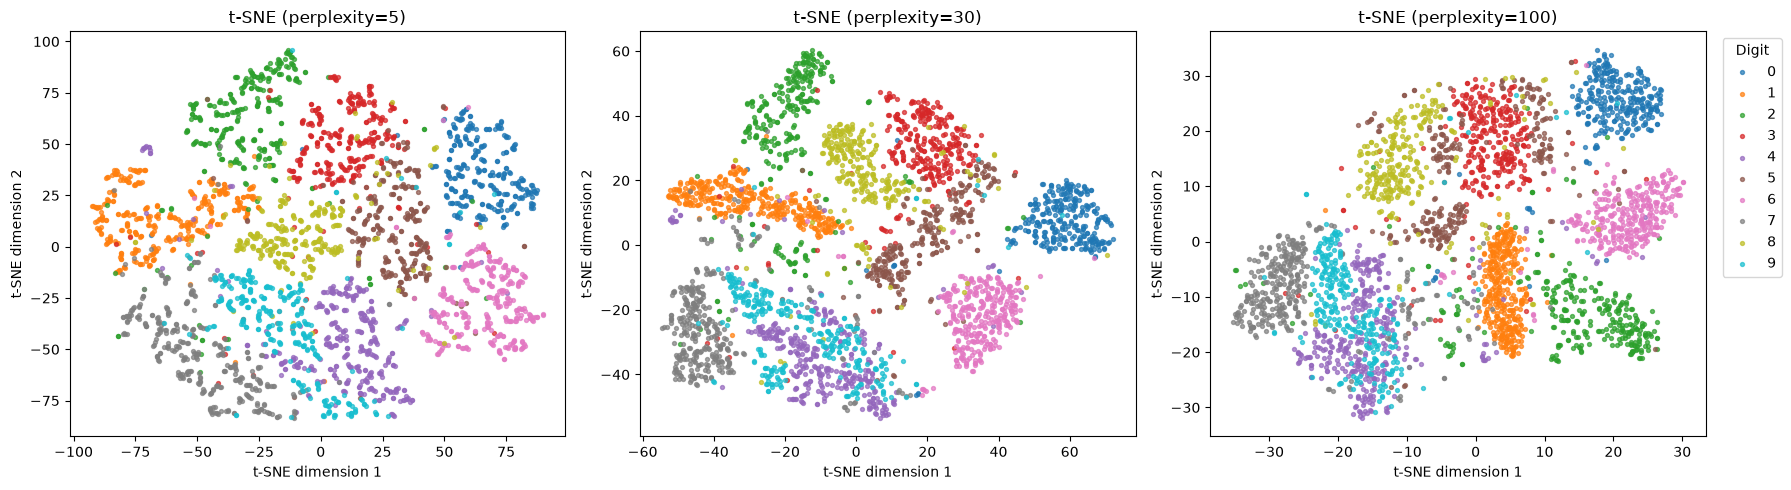

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.manifold import TSNE


# --------------------------------------------------
# 1. Load MNIST
# --------------------------------------------------

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)


# --------------------------------------------------
# 2. Take the same subset
# --------------------------------------------------

X = X[:3000]
y = y[:3000]

print("X shape:", X.shape)
print("y shape:", y.shape)


# --------------------------------------------------
# 3. Run t-SNE for different perplexities
# --------------------------------------------------

perplexities = [5, 30, 100]

results = {}

for perplexity in perplexities:

    print(f"Running t-SNE with perplexity = {perplexity}")

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )

    X_tsne = tsne.fit_transform(X)

    results[perplexity] = X_tsne


# --------------------------------------------------
# 4. Plot the three results
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

for ax, perplexity in zip(axes, perplexities):

    X_tsne = results[perplexity]

    for digit in range(10):

        mask = y == digit

        ax.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            s=8,
            alpha=0.7,
            label=str(digit)
        )

    ax.set_title(f"t-SNE (perplexity={perplexity})")
    ax.set_xlabel("t-SNE dimension 1")
    ax.set_ylabel("t-SNE dimension 2")

axes[-1].legend(
    title="Digit",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Take a dataset with 50 features where only 5 are informative (generate one with sklearn.datasets.make_classification). Apply PCA and check whether the explained variance curve correctly identifies that the data is effectively 5-dimensional.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


# --------------------------------------------------
# 1. Generate dataset
# --------------------------------------------------

X, y = make_classification(
    n_samples=5000,
    n_features=50,
    n_informative=5,
    n_redundant=0,
    n_repeated=0,
    random_state=42
)

print("Dataset shape:", X.shape)

Dataset shape: (5000, 50)


In [8]:
pca = PCA(n_components=50)
pca.fit(X)

explained_variance = pca.explained_variance_ratio_

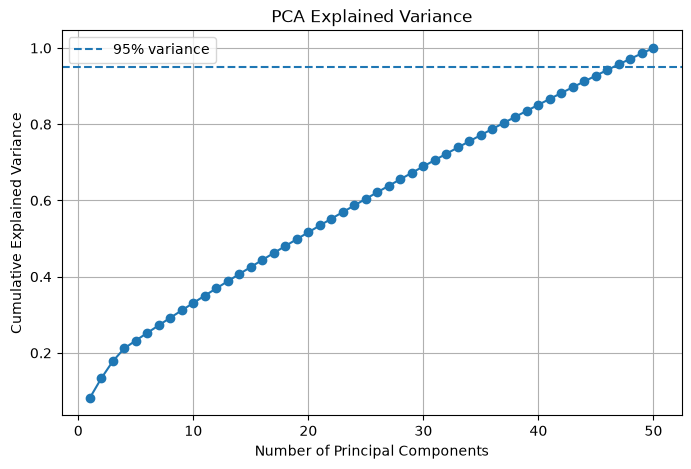

In [9]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 51),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.legend()

plt.show()